<a href="https://colab.research.google.com/github/jeeva477/NLP/blob/main/NLP_Project_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import nltk
import string
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
nltk.download("stopwords")
nltk.download("wordnet")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [2]:
data = {

"Review":[

# ---------------- Positive ----------------

"The hotel room was spacious, clean, and beautifully decorated.",
"The front desk staff welcomed us warmly and completed check-in quickly.",
"The breakfast buffet offered many fresh and delicious dishes.",
"The housekeeping team kept our room spotless every day.",
"The hotel location was close to shopping malls and tourist attractions.",
"The swimming pool was clean and well maintained.",
"The gym had modern equipment and enough space to exercise.",
"The WiFi connection was fast throughout the hotel.",
"The restaurant served delicious food with excellent customer service.",
"The bed was very comfortable and provided a good night's sleep.",
"The bathroom was sparkling clean with fresh towels.",
"The hotel staff handled every request professionally.",
"The room service arrived earlier than expected.",
"The complimentary breakfast exceeded our expectations.",
"The hotel lobby looked elegant and luxurious.",
"The children enjoyed the indoor play area.",
"The air conditioning worked perfectly during our stay.",
"The parking facility was secure and easy to access.",
"The hotel offered great value for the money.",
"The receptionist upgraded our room without additional charges.",
"The view from our balcony was absolutely amazing.",
"The check-out process was smooth and hassle-free.",
"The hotel management resolved our request immediately.",
"The coffee served during breakfast was excellent.",
"The elevators were fast and always available.",
"The hotel atmosphere was peaceful and relaxing.",
"The conference hall was well organized for our business meeting.",
"The hotel provided excellent airport transportation.",
"The staff always greeted guests with a smile.",
"Our family had a wonderful and memorable stay.",

# ---------------- Negative ----------------

"The room smelled bad and the bedsheets were dirty.",
"The bathroom had leaking taps and was not cleaned properly.",
"The receptionist was rude and ignored our complaints.",
"The breakfast was cold and lacked variety.",
"The room service took more than an hour to deliver food.",
"The WiFi connection disconnected every few minutes.",
"The air conditioner was not working properly.",
"The swimming pool was closed without prior notice.",
"The gym equipment was broken and outdated.",
"The parking area was overcrowded and unsafe.",
"The hotel location was far from public transportation.",
"The staff behaved unprofessionally during check-out.",
"The room was much smaller than shown in the pictures.",
"The towels were old, stained, and unpleasant.",
"The food quality was disappointing and overpriced.",
"There was loud noise from neighboring rooms all night.",
"The elevator stopped working several times.",
"The hotel management did not respond to our complaints.",
"The restaurant service was extremely slow.",
"The bathroom had an unpleasant smell throughout our stay.",
"The room was not ready even after check-in time.",
"The housekeeping staff forgot to replace toiletries.",
"The internet speed was extremely slow.",
"The mattress was uncomfortable and caused back pain.",
"The hotel looked old and poorly maintained.",
"The conference room lacked proper air conditioning.",
"The children play area was damaged and unsafe.",
"The airport pickup service never arrived.",
"The lighting inside the room was too dim.",
"Our overall experience was disappointing and not worth the money."

],

"Sentiment":[

# Positive (30)

"Positive","Positive","Positive","Positive","Positive",
"Positive","Positive","Positive","Positive","Positive",
"Positive","Positive","Positive","Positive","Positive",
"Positive","Positive","Positive","Positive","Positive",
"Positive","Positive","Positive","Positive","Positive",
"Positive","Positive","Positive","Positive","Positive",

# Negative (30)

"Negative","Negative","Negative","Negative","Negative",
"Negative","Negative","Negative","Negative","Negative",
"Negative","Negative","Negative","Negative","Negative",
"Negative","Negative","Negative","Negative","Negative",
"Negative","Negative","Negative","Negative","Negative",
"Negative","Negative","Negative","Negative","Negative"

]

}

df = pd.DataFrame(data)

print("\nDataset Shape :", df.shape)
print(df.head())



Dataset Shape : (60, 2)
                                              Review Sentiment
0  The hotel room was spacious, clean, and beauti...  Positive
1  The front desk staff welcomed us warmly and co...  Positive
2  The breakfast buffet offered many fresh and de...  Positive
3  The housekeeping team kept our room spotless e...  Positive
4  The hotel location was close to shopping malls...  Positive


In [3]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def preprocess(text):

    text = text.lower()

    text = text.translate(str.maketrans("", "", string.punctuation))

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["Clean_Review"] = df["Review"].apply(preprocess)

print("\nPreprocessed Reviews")
print(df[["Review","Clean_Review"]].head())




Preprocessed Reviews
                                              Review  \
0  The hotel room was spacious, clean, and beauti...   
1  The front desk staff welcomed us warmly and co...   
2  The breakfast buffet offered many fresh and de...   
3  The housekeeping team kept our room spotless e...   
4  The hotel location was close to shopping malls...   

                                        Clean_Review  
0    hotel room spacious clean beautifully decorated  
1  front desk staff welcomed u warmly completed c...  
2  breakfast buffet offered many fresh delicious ...  
3     housekeeping team kept room spotless every day  
4  hotel location close shopping mall tourist att...  


In [4]:
X = df["Clean_Review"]
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
model = Pipeline([

    ("tfidf",TfidfVectorizer()),

    ("classifier",MultinomialNB())

])

model.fit(X_train,y_train)

print("\nModel Trained Successfully")



Model Trained Successfully


In [6]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test,predictions)

print("\nAccuracy : {:.2f}%".format(accuracy*100))

print("\nClassification Report\n")
print(classification_report(y_test,predictions))



Accuracy : 50.00%

Classification Report

              precision    recall  f1-score   support

    Negative       0.50      0.50      0.50         6
    Positive       0.50      0.50      0.50         6

    accuracy                           0.50        12
   macro avg       0.50      0.50      0.50        12
weighted avg       0.50      0.50      0.50        12



In [8]:
issues = {

    "Room Quality":[
        "room","bed","bedsheet","mattress","balcony","lighting"
    ],

    "Cleanliness":[
        "clean","dirty","bathroom","towel","toiletries","housekeeping","smell"
    ],

    "Staff Behaviour":[
        "staff","receptionist","management","service","checkin","checkout"
    ],

    "Food Service":[
        "food","restaurant","breakfast","coffee","dinner","buffet"
    ],

    "Amenities":[
        "wifi","internet","pool","gym","parking","air","conditioning","elevator","play"
    ],

    "Location & Transport":[
        "location","airport","transportation","pickup"
    ]

}

issue_count = {category:0 for category in issues}

negative_reviews = df[df["Sentiment"]=="Negative"]["Clean_Review"]

for review in negative_reviews:

    for category,keywords in issues.items():

        if any(word in review for word in keywords):

            issue_count[category]+=1

issue_df = pd.DataFrame(

    issue_count.items(),

    columns=["Service Area","Number of Complaints"]

)

print("\nService Issue Report")
print(issue_df)


Service Issue Report
           Service Area  Number of Complaints
0          Room Quality                    10
1           Cleanliness                     5
2       Staff Behaviour                     8
3          Food Service                     4
4             Amenities                    10
5  Location & Transport                     2


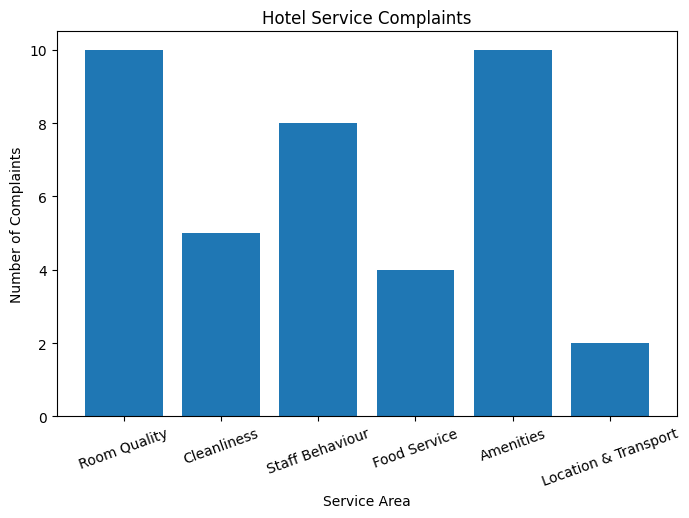

In [9]:
plt.figure(figsize=(8,5))

plt.bar(issue_df["Service Area"],
        issue_df["Number of Complaints"])

plt.title("Hotel Service Complaints")

plt.xlabel("Service Area")

plt.ylabel("Number of Complaints")

plt.xticks(rotation=20)

plt.show()

In [10]:
positive = len(df[df["Sentiment"]=="Positive"])
negative = len(df[df["Sentiment"]=="Negative"])
total = len(df)

satisfaction = (positive/total)*100

print("\n==============================")
print("CUSTOMER SATISFACTION REPORT")
print("==============================")

print("Total Reviews :",total)
print("Positive Reviews :",positive)
print("Negative Reviews :",negative)
print("Customer Satisfaction : {:.2f}%".format(satisfaction))

print("\nTop Complaint Areas")
print(issue_df.sort_values(
    by="Number of Complaints",
    ascending=False
))


CUSTOMER SATISFACTION REPORT
Total Reviews : 60
Positive Reviews : 30
Negative Reviews : 30
Customer Satisfaction : 50.00%

Top Complaint Areas
           Service Area  Number of Complaints
0          Room Quality                    10
4             Amenities                    10
2       Staff Behaviour                     8
1           Cleanliness                     5
3          Food Service                     4
5  Location & Transport                     2


In [11]:
new_reviews = [

"The hotel room was clean, spacious, and beautifully maintained.",

"The receptionist was rude and the room was dirty.",

"The breakfast buffet had many delicious dishes.",

"The WiFi was slow and the air conditioner stopped working.",

"The swimming pool and gym were excellent.",

"The towels smelled bad and the bathroom was dirty.",

"The hotel location was perfect for sightseeing.",

"The restaurant served cold food with poor service.",

"The staff were polite and solved our problem immediately.",

"The parking area was unsafe and overcrowded."

]

print("\n==============================")
print("NEW REVIEW PREDICTIONS")
print("==============================")

for review in new_reviews:

    clean = preprocess(review)

    prediction = model.predict([clean])[0]

    print("\nReview :",review)

    print("Predicted Sentiment :",prediction)



NEW REVIEW PREDICTIONS

Review : The hotel room was clean, spacious, and beautifully maintained.
Predicted Sentiment : Positive

Review : The receptionist was rude and the room was dirty.
Predicted Sentiment : Negative

Review : The breakfast buffet had many delicious dishes.
Predicted Sentiment : Positive

Review : The WiFi was slow and the air conditioner stopped working.
Predicted Sentiment : Negative

Review : The swimming pool and gym were excellent.
Predicted Sentiment : Positive

Review : The towels smelled bad and the bathroom was dirty.
Predicted Sentiment : Negative

Review : The hotel location was perfect for sightseeing.
Predicted Sentiment : Positive

Review : The restaurant served cold food with poor service.
Predicted Sentiment : Negative

Review : The staff were polite and solved our problem immediately.
Predicted Sentiment : Positive

Review : The parking area was unsafe and overcrowded.
Predicted Sentiment : Negative
